In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy import stats as spstats
import librosa
from IPython.display import Audio, display

from scipy.io import wavfile
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 3)
plt.rcParams['axes.grid'] = True

RNG = np.random.default_rng(42)
FS = 2000  # Hz — cuantas muestras por segundo va a tener nuestro audio de prueba

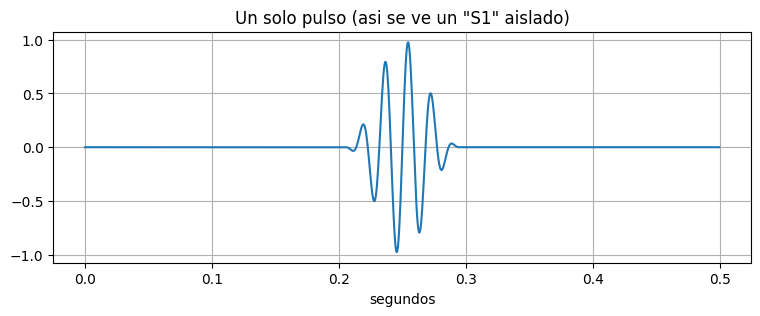

In [14]:
def hann_pulse(t, center, dur, freq, amp):
    out = np.zeros_like(t)                                  # empezamos en puro silencio
    mask = (t >= center - dur/2) & (t <= center + dur/2)     # que parte del tiempo cae dentro del pulso
    n = mask.sum()
    if n == 0:
        return out
    window = np.hanning(n)                                  # la envolvente: sube y baja suave
    carrier = np.sin(2*np.pi*freq*(t[mask]-center))          # el tono puro (seno)
    out[mask] = amp * window * carrier                       # tono x envolvente = pulso limpio
    return out

# probemoslo con un pulso aislado, para verlo solo
t = np.arange(0, 0.5, 1/FS)   # medio segundo, casi todo va a ser silencio
pulso = hann_pulse(t, center=0.25, dur=0.09, freq=55, amp=1.0)

plt.plot(t, pulso)
plt.title('Un solo pulso (asi se ve un "S1" aislado)')
plt.xlabel('segundos')
plt.show()

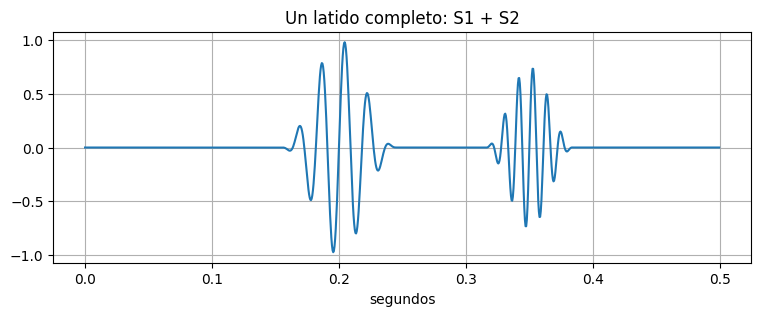

In [15]:
# S1: grave
s1 = hann_pulse(t, center=0.20, dur=0.09, freq=55, amp=1.0)

# S2: agudo
s2 = hann_pulse(t, center=0.35, dur=0.07, freq=90, amp=0.75)

latido = s1 + s2

plt.plot(t, latido)
plt.title('Un latido completo: S1 + S2')
plt.xlabel('segundos')
plt.show()

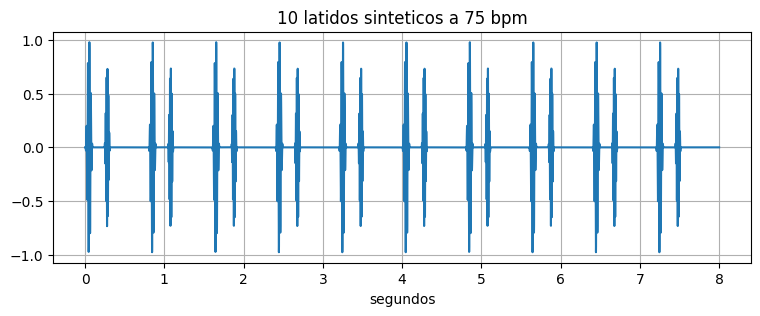

In [16]:
bpm = 75                       # latidos por minuto
cycle_len = 60.0 / bpm         # segundos que dura CADA latido
duracion = 8.0                 # segundos totales de la grabacion
t = np.arange(0, duracion, 1/FS)   # reloj nuevo, mas largo que el de antes

señal = np.zeros_like(t)
n_ciclos = int(duracion / cycle_len)

for i in range(n_ciclos):
    inicio_ciclo = i * cycle_len
    s1 = hann_pulse(t, center=inicio_ciclo + 0.05, dur=0.09, freq=55, amp=1.0)
    s2 = hann_pulse(t, center=inicio_ciclo + 0.35*cycle_len, dur=0.07, freq=90, amp=0.75)
    señal += s1 + s2

plt.plot(t, señal)
plt.title(f'{n_ciclos} latidos sinteticos a {bpm} bpm')
plt.xlabel('segundos')
plt.show()

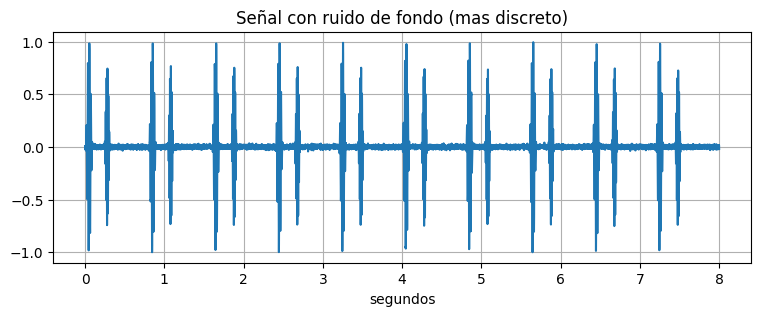

In [17]:
# normalizamos el latido SOLO (sin ruido todavia), para asegurar que los
# pulsos S1/S2 lleguen a su volumen maximo
señal_normalizada = señal / np.max(np.abs(señal))

# ruido bastante mas discreto que antes (0.01 en vez de 0.03)
ruido = RNG.normal(0, 0.01, size=t.shape)
señal_final = señal_normalizada + ruido

# por si el ruido empujo algun punto un poquito arriba de 1, reacomodamos otra vez
señal_final = señal_final / np.max(np.abs(señal_final))

plt.plot(t, señal_final)
plt.title('Señal con ruido de fondo (mas discreto)')
plt.xlabel('segundos')
plt.show()

audio_int16 = (señal_final * 32767).astype(np.int16)
wavfile.write('ejemplo_latido.wav', FS, audio_int16)
display(Audio('ejemplo_latido.wav'))

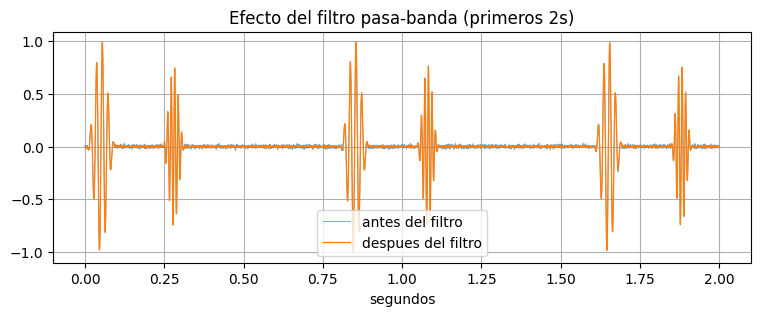

In [18]:
#pasabanda
def bandpass(sig, fs, low=25, high=400, order=4):
    nyquist = fs / 2
    b, a = butter(order, [low/nyquist, high/nyquist], btype='band')
    return filtfilt(b, a, sig)

señal_filtrada = bandpass(señal_final, FS)

plt.figure()
plt.plot(t[:int(2*FS)], señal_final[:int(2*FS)], linewidth=0.7, alpha=0.6, label='antes del filtro')
plt.plot(t[:int(2*FS)], señal_filtrada[:int(2*FS)], linewidth=0.9, label='despues del filtro')
plt.legend()
plt.xlabel('segundos')
plt.title('Efecto del filtro pasa-banda (primeros 2s)')
plt.show()

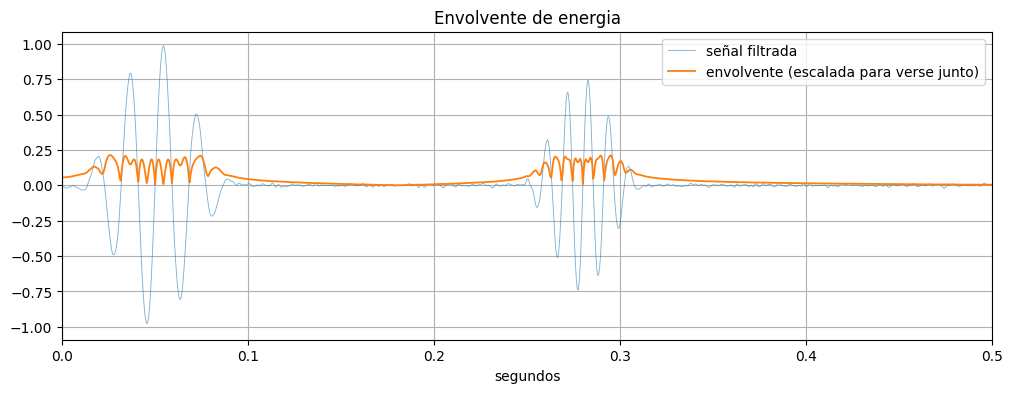

In [19]:
def shannon_envelope(sig):
    x = sig / np.max(np.abs(sig))
    energia = x**2
    energia = np.clip(energia, 1e-9, None)
    shannon = -energia * np.log(energia)
    envolvente = np.abs(hilbert(shannon))
    return envolvente

envolvente = shannon_envelope(señal_filtrada)

plt.figure(figsize=(12, 4))
t2 = t[:int(3*FS)]
plt.plot(t2, señal_filtrada[:int(3*FS)], linewidth=0.6, alpha=0.6, label='señal filtrada')
plt.plot(t2, envolvente[:int(3*FS)]*0.5, linewidth=1.3, label='envolvente (escalada para verse junto)')
plt.legend()
plt.xlabel('segundos')
plt.title('Envolvente de energia')
plt.xlim(0, .5)  # solo el primer .5s, en vez de los 3s completos
plt.show()

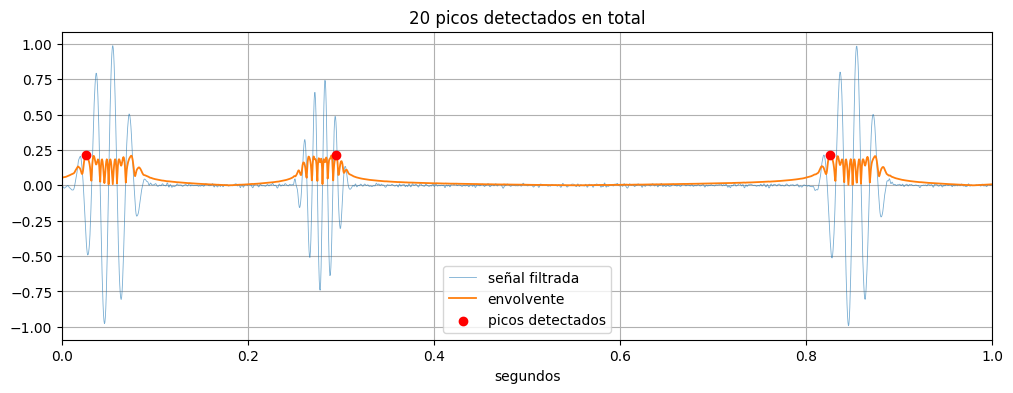

In [20]:
picos = find_peaks(envolvente, distance=int(FS*60/180/2.2), prominence=np.std(envolvente)*0.5)[0]

plt.figure(figsize=(12, 4))
t2 = t[:int(3*FS)]
plt.plot(t2, señal_filtrada[:int(3*FS)], linewidth=0.6, alpha=0.6, label='señal filtrada')
plt.plot(t2, envolvente[:int(3*FS)]*0.5, linewidth=1.3, label='envolvente')
picos_en_rango = picos[picos < int(3*FS)]
plt.scatter(t[picos_en_rango], envolvente[picos_en_rango]*0.5, color='red', zorder=5, label='picos detectados')
plt.legend()
plt.xlabel('segundos')
plt.xlim(0, 1)
plt.title(f'{len(picos)} picos detectados en total')
plt.show()

forma del resultado (filas, columnas): (8, 32)


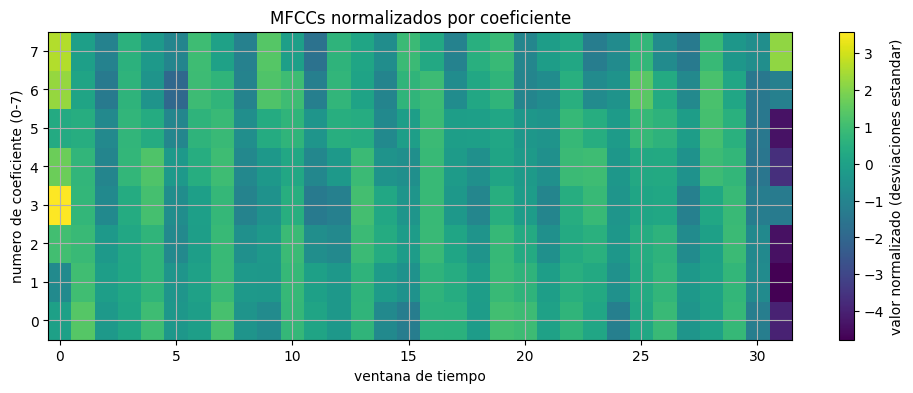

In [22]:
mfcc = librosa.feature.mfcc(y=señal_filtrada.astype(float), sr=FS, n_mfcc=8)
print("forma del resultado (filas, columnas):", mfcc.shape)
mfcc_normalizado = (mfcc - mfcc.mean(axis=1, keepdims=True)) / mfcc.std(axis=1, keepdims=True)

plt.figure(figsize=(12, 4))
plt.imshow(mfcc_normalizado, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='valor normalizado (desviaciones estandar)')
plt.ylabel('numero de coeficiente (0-7)')
plt.xlabel('ventana de tiempo')
plt.title('MFCCs normalizados por coeficiente')
plt.show()

In [23]:
mfcc_promedio = mfcc.mean(axis=1)
mfcc_variacion = mfcc.std(axis=1)

print("forma de mfcc_promedio:", mfcc_promedio.shape)
print("forma de mfcc_variacion:", mfcc_variacion.shape)

feats = {}
for i in range(8):
    feats[f'mfcc{i+1}_promedio'] = float(mfcc_promedio[i])
    feats[f'mfcc{i+1}_variacion'] = float(mfcc_variacion[i])

print(feats)

forma de mfcc_promedio: (8,)
forma de mfcc_variacion: (8,)
{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264}


In [24]:
feats['env_promedio'] = float(np.mean(envolvente))
feats['env_variacion'] = float(np.std(envolvente))
feats['env_asimetria'] = float(spstats.skew(envolvente))
feats['env_apuntamiento'] = float(spstats.kurtosis(envolvente))

intervalos = np.diff(picos) / FS
feats['intervalo_promedio'] = float(np.mean(intervalos))
feats['intervalo_variacion'] = float(np.std(intervalos))

print(feats)

{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264, 'env_promedio': 0.07380307255049086, 'env_variacion': 0.10138702773757438, 'env_asimetria': 1.969101032726706, 'env_apuntamiento': 2.875406321808245, 'intervalo_promedio': 0.39281578947368423, 'intervalo_variacion': 0.13158219469677057}


In [25]:
def extract_features(señal_cruda, fs):
    # preprocesamiento (celda 6)
    señal_filtrada = bandpass(señal_cruda, fs)

    # segmentacion (celdas 7 y 8)
    envolvente = shannon_envelope(señal_filtrada)
    picos = find_peaks(envolvente, distance=int(fs*60/180/2.2), prominence=np.std(envolvente)*0.5)[0]

    # features de MFCC (celdas 9 y 10)
    mfcc = librosa.feature.mfcc(y=señal_filtrada.astype(float), sr=fs, n_mfcc=8)
    mfcc_promedio = mfcc.mean(axis=1)
    mfcc_variacion = mfcc.std(axis=1)

    feats = {}
    for i in range(8):
        feats[f'mfcc{i+1}_promedio'] = float(mfcc_promedio[i])
        feats[f'mfcc{i+1}_variacion'] = float(mfcc_variacion[i])

    # features de la envolvente (celda 11)
    feats['env_promedio'] = float(np.mean(envolvente))
    feats['env_variacion'] = float(np.std(envolvente))
    feats['env_asimetria'] = float(spstats.skew(envolvente))
    feats['env_apuntamiento'] = float(spstats.kurtosis(envolvente))

    # features de intervalos (celda 11), con seguro por si detecta muy pocos picos
    if len(picos) > 1:
        intervalos = np.diff(picos) / fs
        feats['intervalo_promedio'] = float(np.mean(intervalos))
        feats['intervalo_variacion'] = float(np.std(intervalos))
    else:
        feats['intervalo_promedio'] = 0.0
        feats['intervalo_variacion'] = 0.0

    return feats

# la probamos con la misma grabacion de siempre, para confirmar que da los mismos numeros
feats_prueba = extract_features(señal_final, FS)
print(feats_prueba)

{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264, 'env_promedio': 0.07380307255049086, 'env_variacion': 0.10138702773757438, 'env_asimetria': 1.969101032726706, 'env_apuntamiento': 2.875406321808245, 'intervalo_promedio': 0.39281578947368423, 'intervalo_variacion': 0.13158219469677057}


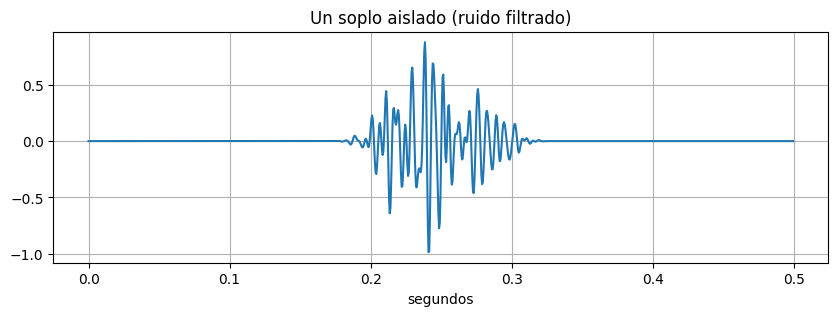

In [26]:
def soplo(t, centro, duracion, amp, fs, rng):
    out = np.zeros_like(t)
    mask = (t >= centro - duracion/2) & (t <= centro + duracion/2)
    n = mask.sum()
    if n == 0:
        return out
    ventana = np.hanning(n)
    ruido_blanco = rng.normal(0, 1, n)
    b, a = butter(4, [80/(fs/2), 250/(fs/2)], btype='band')
    ruido_filtrado = filtfilt(b, a, ruido_blanco)
    out[mask] = amp * ventana * ruido_filtrado
    return out

# probemoslo aislado, como hicimos con el pulso al principio
t_prueba = np.arange(0, 0.5, 1/FS)
ejemplo_soplo = soplo(t_prueba, centro=0.25, duracion=0.15, amp=1.0, fs=FS, rng=RNG)

plt.figure(figsize=(10, 3))
plt.plot(t_prueba, ejemplo_soplo)
plt.title('Un soplo aislado (ruido filtrado)')
plt.xlabel('segundos')
plt.show()

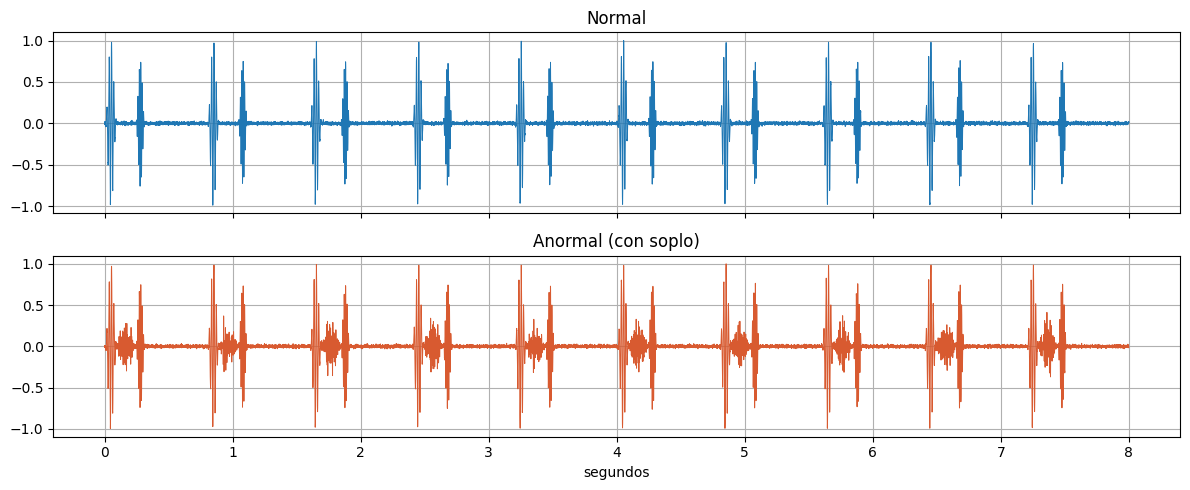

Normal:


Anormal:


In [29]:
def generar_grabacion(bpm, duracion, anormal, fs, rng):
    t = np.arange(0, duracion, 1/fs)
    cycle_len = 60.0 / bpm
    señal = np.zeros_like(t)
    n_ciclos = int(duracion / cycle_len)

    for i in range(n_ciclos):
        inicio_ciclo = i * cycle_len
        s1_centro = inicio_ciclo + 0.05
        s2_centro = inicio_ciclo + 0.35*cycle_len
        s1 = hann_pulse(t, center=s1_centro, dur=0.09, freq=55, amp=1.0)
        s2 = hann_pulse(t, center=s2_centro, dur=0.07, freq=90, amp=0.75)
        señal += s1 + s2

        if anormal:
            centro_soplo = s1_centro + 0.5*(s2_centro - s1_centro)
            duracion_soplo = (s2_centro - s1_centro) - 0.05
            señal += soplo(t, centro=centro_soplo, duracion=duracion_soplo, amp=0.4, fs=fs, rng=rng)

    señal = señal / np.max(np.abs(señal))
    ruido = rng.normal(0, 0.01, size=t.shape)
    señal = señal + ruido
    señal = señal / np.max(np.abs(señal))
    return t, señal

t, grabacion_normal = generar_grabacion(bpm=75, duracion=8.0, anormal=False, fs=FS, rng=RNG)
t, grabacion_anormal = generar_grabacion(bpm=75, duracion=8.0, anormal=True, fs=FS, rng=RNG)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, grabacion_normal, linewidth=0.7)
axes[0].set_title('Normal')
axes[1].plot(t, grabacion_anormal, linewidth=0.7, color='#D85A30')
axes[1].set_title('Anormal (con soplo)')
axes[1].set_xlabel('segundos')
plt.tight_layout()
plt.show()

print("Normal:")
display(Audio(grabacion_normal, rate=FS))
print("Anormal:")
display(Audio(grabacion_anormal, rate=FS))

audio_int16 = (grabacion_anormal * 32767).astype(np.int16)
wavfile.write('ejemplo_latido_anormal.wav', FS, audio_int16)
